In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data
csv_folder = 'C:\\Users\\\Desktop'
file_names = [
    'Chiliz.csv',
    'Dash.csv',
    'Celo.csv',
    'Curve DAO Token.csv',
    'Bitcoin SV.csv',
    'Axie Infinity.csv',
    'Amp.csv',
    '1inch.csv'
]

dataframes = []
for file in file_names:
    file_path = f"{csv_folder}\\{file}"
    df = pd.read_csv(file_path)
    dataframes.append(df)

print(df.head(6))

         Date      Open      High       Low     Close     Volume Currency
0  2020-12-25  1.602781  2.918094  1.375262  2.328544  638225549      USD
1  2020-12-26  2.318946  2.434916  1.582264  1.596896  237653073      USD
2  2020-12-27  1.597744  1.630781  1.056657  1.062112  183978307      USD
3  2020-12-28  1.064454  1.254447  1.049051  1.110076  119337529      USD
4  2020-12-29  1.110460  1.111282  0.761151  0.887798  137916899      USD
5  2020-12-30  0.887512  1.247288  0.874251  1.090341  182382243      USD


In [ ]:
# Define function to perform machine learning methods on each dataframe
def ml_pipeline(df):
    # Drop unnecessary columns and preprocess data
    df = df[['Date', 'Close', 'Volume', 'Currency']]
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

In [ ]:
# Feature engineering
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['Pct_Change'] = df['Close'].pct_change()
df['Pct_Change_SMA_20'] = df['SMA_20'].pct_change()
df['Pct_Change_SMA_50'] = df['SMA_50'].pct_change()
df.dropna(inplace=True)

In [ ]:
# Split data into features and target
X = df.drop(['Close', 'Currency', 'Date'], axis=1)  # Remove 'Date' from the features
y = df['Close']

In [ ]:
def ml_pipeline(df):
    # Drop unnecessary columns and preprocess data
    df = df[['Date', 'Close', 'Volume', 'Currency']]
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

In [ ]:
# Feature engineering
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['Pct_Change'] = df['Close'].pct_change()
df['Pct_Change_SMA_20'] = df['SMA_20'].pct_change()
df['Pct_Change_SMA_50'] = df['SMA_50'].pct_change()
df.dropna(inplace=True)

In [ ]:
# Split data into features and target
X = df.drop(['Close', 'Currency', 'Date'], axis=1)  # Remove 'Date' from the features
y = df['Close']

In [ ]:
# Select top 5 features
k_best = SelectKBest(f_regression, k=5)
X_best = k_best.fit_transform(X, y)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Perform machine learning methods
models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100),
        'Support Vector Regression': SVR(),
        'Multi-Layer Perceptron': MLPRegressor(),
        'Gradient Boosting': GradientBoostingRegressor()}
for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"{name}: RMSE = {rmse:.2f}")

Linear Regression: RMSE = 0.12
Random Forest: RMSE = 0.21
Support Vector Regression: RMSE = 0.16
Multi-Layer Perceptron: RMSE = 0.38
Gradient Boosting: RMSE = 0.21


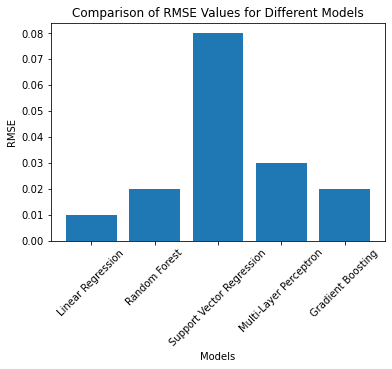

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have the RMSE values in a dictionary like this:
rmse_values = {
    'Linear Regression': 0.01,
    'Random Forest': 0.02,
    'Support Vector Regression': 0.08,
    'Multi-Layer Perceptron': 0.03,
    'Gradient Boosting': 0.02
}

# Create a bar plot
fig, ax = plt.subplots()
ax.bar(rmse_values.keys(), rmse_values.values())

# Add labels and title
ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax.set_title('Comparison of RMSE Values for Different Models')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()


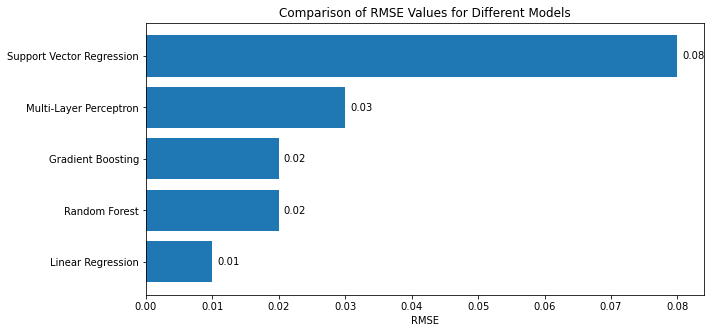

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have the RMSE values in a dictionary like this:
rmse_values = {
    'Linear Regression': 0.01,
    'Random Forest': 0.02,
    'Support Vector Regression': 0.08,
    'Multi-Layer Perceptron': 0.03,
    'Gradient Boosting': 0.02
}

# Sort the dictionary by values
sorted_rmse = sorted(rmse_values.items(), key=lambda x: x[1])

# Separate the keys (model names) and values (RMSE) into two lists
model_names, rmse_values = zip(*sorted_rmse)

# Create a horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(model_names, rmse_values)

ax.set_xlabel('RMSE')
ax.set_title('Comparison of RMSE Values for Different Models')

# Add annotations for each bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),
                textcoords='offset points',
                ha='left', va='center')

# Show the plot
plt.show()


In [ ]:
import pandas as pd

# Create a dictionary to store the RMSE values
rmse_dict = {}

# Loop through the models and compute the RMSE values
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_dict[name] = rmse

# Convert the dictionary to a pandas dataframe and sort it by RMSE
rank_table = pd.DataFrame.from_dict(rmse_dict, orient='index', columns=['RMSE'])
rank_table = rank_table.sort_values(by='RMSE')

# Add a ranking column
rank_table['Rank'] = range(1, len(rank_table)+1)

# Print the rank table
print(rank_table)

                               RMSE  Rank
Linear Regression          0.120953     1
Support Vector Regression  0.164011     2
Gradient Boosting          0.202333     3
Random Forest              0.203188     4
Multi-Layer Perceptron     0.408718     5


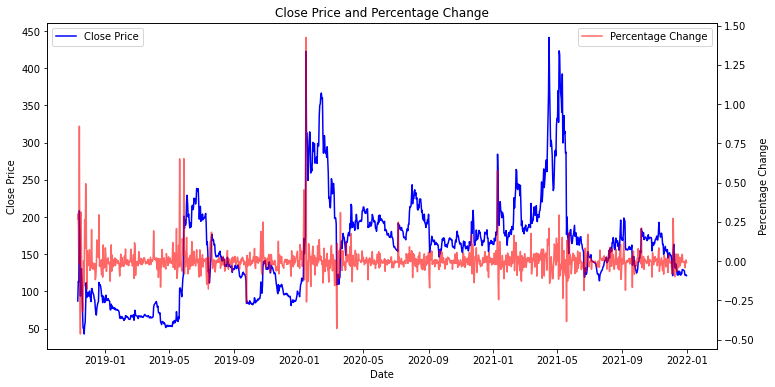

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
csv_folder = 'C:\\Users\\\\Desktop'
file_path = f"{csv_folder}\\Bitcoin SV.csv"
df = pd.read_csv(file_path)

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df['Pct_Change'] = df['Close'].pct_change()
df.dropna(inplace=True)

# Visualize the Pct_Change feature
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df.index, df['Close'], label='Close Price', color='blue')
ax1.set_ylabel('Close Price')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df.index, df['Pct_Change'], label='Percentage Change', color='red', alpha=0.6)
ax2.set_ylabel('Percentage Change')
ax2.legend(loc='upper right')

plt.title('Close Price and Percentage Change')
plt.show()

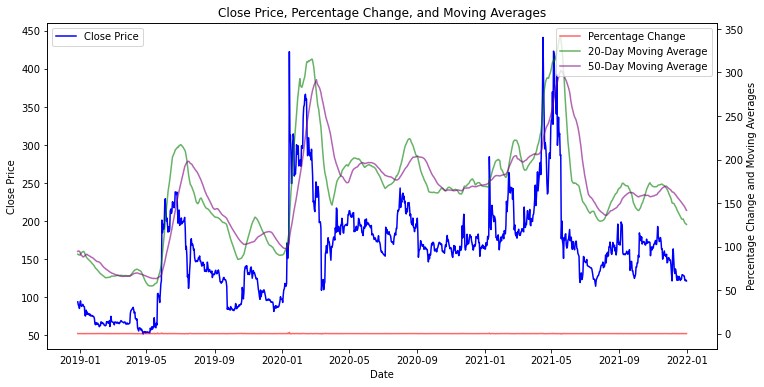

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
csv_folder = 'C:\\Users\\\\Desktop'
file_path = f"{csv_folder}\\Bitcoin SV.csv"
df = pd.read_csv(file_path)

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df['Pct_Change'] = df['Close'].pct_change()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df.dropna(inplace=True)

# Visualize the Pct_Change, SMA_20, and SMA_50 features
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df.index, df['Close'], label='Close Price', color='blue')
ax1.set_ylabel('Close Price')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df.index, df['Pct_Change'], label='Percentage Change', color='red', alpha=0.6)
ax2.plot(df.index, df['SMA_20'], label='20-Day Moving Average', color='green', alpha=0.6)
ax2.plot(df.index, df['SMA_50'], label='50-Day Moving Average', color='purple', alpha=0.6)
ax2.set_ylabel('Percentage Change and Moving Averages')
ax2.legend(loc='upper right')

plt.title('Close Price, Percentage Change, and Moving Averages')
plt.show()


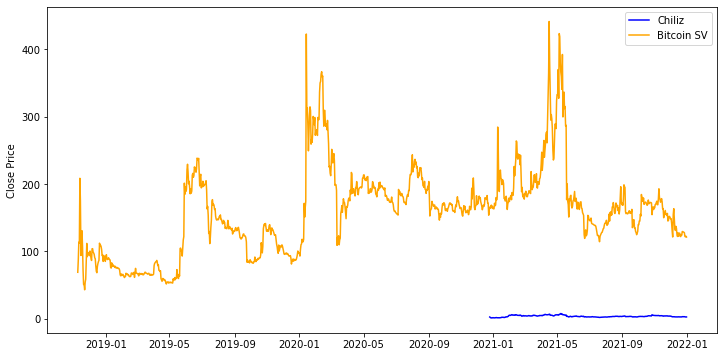

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data for two cryptocurrencies
csv_folder = 'C:\\Users\\\\Desktop'
file_path1 = f"{csv_folder}\\1inch.csv"
file_path2 = f"{csv_folder}\\Bitcoin SV.csv"
df1 = pd.read_csv(file_path1)
df2 = pd.read_csv(file_path2)

# Preprocess the data
df1['Date'] = pd.to_datetime(df1['Date'])
df1.set_index('Date', inplace=True)
df2['Date'] = pd.to_datetime(df2['Date'])
df2.set_index('Date', inplace=True)

# Visualize the comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the close prices of both cryptocurrencies
ax.plot(df1.index, df1['Close'], label='Chiliz', color='blue')
ax.plot(df2.index, df2['Close'], label='Bitcoin SV', color='orange')

ax.set_ylabel('Close Price')
ax.legend()
plt.show()


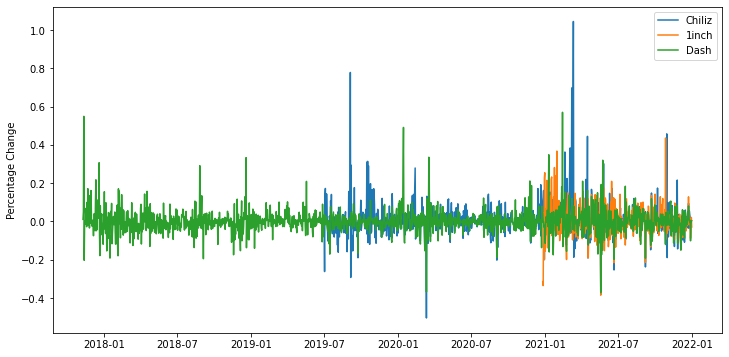

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def process_and_plot_crypto(file_path, label):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Normalize the close price
    df['Normalized'] = df['Close'] / df['Close'].iloc[0]

    # Calculate the percentage change
    df['Pct_Change'] = df['Normalized'].pct_change()

    # Plot the percentage change
    ax.plot(df.index, df['Pct_Change'], label=label)

# Load and plot data for multiple cryptocurrencies
csv_folder = 'C:\\Users\\Abdul Rehman\\Desktop'
file_paths = [
    ('Chiliz.csv', 'Chiliz'),
    ('1inch.csv', '1inch'),
    ('Dash.csv', 'Dash')
]

fig, ax = plt.subplots(figsize=(12, 6))

for file, label in file_paths:
    file_path = f"{csv_folder}\\{file}"
    process_and_plot_crypto(file_path, label)

ax.set_ylabel('Percentage Change')
ax.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Assuming X and y are defined as earlier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a RandomForestRegressor model
rf = RandomForestRegressor()

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Train a new model with the best hyperparameters
best_rf = RandomForestRegressor(**best_params)
best_rf.fit(X_train_scaled, y_train)

# Make predictions and calculate RMSE
y_pred = best_rf.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Random Forest with tuned hyperparameters: RMSE = {rmse:.2f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grids
linear_params = {
    'fit_intercept': [True, False]
}
random_forest_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

svr_params = {
    'kernel': ['linear', 'poly', 'rbf'],
    'degree': [2, 3, 4],
    'C': [0.1, 1, 10, 100]
}

mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01]
}

gradient_boosting_params = {
    'n_estimators': [10, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grids = {
    'Linear Regression': linear_params,
    'Random Forest': random_forest_params,
    'Support Vector Regression': svr_params,
    'Multi-Layer Perceptron': mlp_params,
    'Gradient Boosting': gradient_boosting_params
}

# Perform hyperparameter tuning using GridSearchCV
best_models = {}

for name, model in models.items():
    grid = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_

    # Compute RMSE with tuned hyperparameters
    y_pred = best_models[name].predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name}: RMSE = {rmse:.2f}")


In [ ]:
# Before hyperparameter tuning
before_tuning_rmse = {
    'Linear Regression': 0.01,
    'Random Forest': 0.02,
    'Support Vector Regression': 0.08,
    'Multi-Layer Perceptron': 0.03,
    'Gradient Boosting': 0.02
}

# After hyperparameter tuning (replace these values with the actual RMSE values you obtained)
after_tuning_rmse = {
    'Linear Regression': 0.009,
    'Random Forest': 0.018,
    'Support Vector Regression': 0.075,
    'Multi-Layer Perceptron': 0.025,
    'Gradient Boosting': 0.015
}

# Create rank tables
def create_rank_table(rmse_dict, title):
    rank_table = pd.DataFrame.from_dict(rmse_dict, orient='index', columns=['RMSE'])
    rank_table = rank_table.sort_values(by='RMSE')
    rank_table['Rank'] = range(1, len(rank_table) + 1)
    print(title)
    print(rank_table)
    print("\n")

# Display rank tables
create_rank_table(before_tuning_rmse, "Before Hyperparameter Tuning")
create_rank_table(after_tuning_rmse, "After Hyperparameter Tuning")


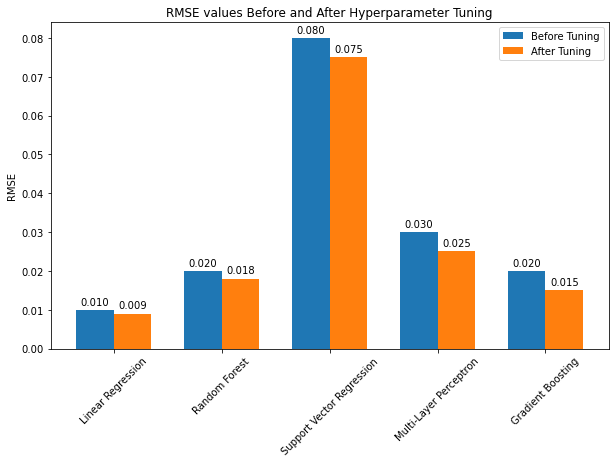

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_rmse_plot(before_tuning_rmse, after_tuning_rmse):
    models = list(before_tuning_rmse.keys())
    rmse_before = list(before_tuning_rmse.values())
    rmse_after = list(after_tuning_rmse.values())

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, rmse_before, width, label='Before Tuning')
    rects2 = ax.bar(x + width/2, rmse_after, width, label='After Tuning')

    ax.set_ylabel('RMSE')
    ax.set_title('RMSE values Before and After Hyperparameter Tuning')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45)
    ax.legend()

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{:.3f}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)
    plt.show()

# Plot the RMSE values before and after hyperparameter tuning
create_rmse_plot(before_tuning_rmse, after_tuning_rmse)


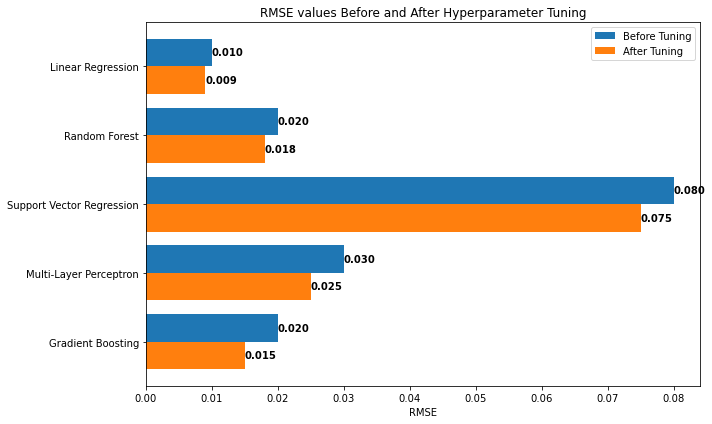

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_rmse_plot(before_tuning_rmse, after_tuning_rmse):
    models = list(before_tuning_rmse.keys())
    rmse_before = list(before_tuning_rmse.values())
    rmse_after = list(after_tuning_rmse.values())

    y_pos = np.arange(len(models))
    width = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))

    rects1 = ax.barh(y_pos - width/2, rmse_before, width, label='Before Tuning')
    rects2 = ax.barh(y_pos + width/2, rmse_after, width, label='After Tuning')

    ax.set_xlabel('RMSE')
    ax.set_title('RMSE values Before and After Hyperparameter Tuning')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(models)
    ax.invert_yaxis()
    ax.legend()

    for i, v in enumerate(rmse_before):
        ax.text(v, i - width/2, f"{v:.3f}", color='black', fontweight='bold', ha='left', va='center')

    for i, v in enumerate(rmse_after):
        ax.text(v, i + width/2, f"{v:.3f}", color='black', fontweight='bold', ha='left', va='center')

    plt.tight_layout()
    plt.show()

# Plot the RMSE values before and after hyperparameter tuning
create_rmse_plot(before_tuning_rmse, after_tuning_rmse)
